# SVR (Support Vector Regressor) - Network Throughput Prediction


## 1. Clone repo (Colab only)

In [1]:
!git clone https://github.com/MohamedAAbdullah1/NTI-Final-Project.git
%cd NTI-Final-Project

Cloning into 'NTI-Final-Project'...
remote: Enumerating objects: 105, done.
remote: Counting objects: 100% (105/105), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 105 (delta 45), reused 43 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (105/105), 3.26 MiB | 6.56 MiB/s, done.
Resolving deltas: 100% (45/45), done.
/content/NTI-Final-Project


## Environment Setup and Imports

The required libraries are imported to support data preprocessing, Support Vector Regression, model evaluation, and model persistence.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR

## Load Training and Testing Data

The prepared training and testing datasets are loaded from the processed data directory. The predefined train-test split is used to maintain consistency across all regression models.

In [3]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape, "| y_test :", y_test.shape)

print("\nTraining features:")
print(X_train.head())

X_train: (13463, 6) | y_train: (13463,)
X_test : (3366, 6) | y_test : (3366,)

Training features:
          Locality   Latitude  Longitude  Signal Strength (dBm)  Latency (ms)  \
0      Pataliputra  25.605539  85.285651             -87.611830    164.101054   
1       Kidwaipuri  25.491973  85.086669             -90.089704     22.851745   
2          Danapur  25.684972  84.989785             -90.175391    139.812003   
3       Kankarbagh  25.569868  85.138714             -93.384826    113.904981   
4  Phulwari Sharif  25.626811  85.136823             -95.888704     71.291449   

  Network Type  
0           4G  
1           5G  
2           4G  
3           4G  
4           4G  


## Define Numerical and Categorical Features

The input features are divided into numerical and categorical groups to ensure that each feature type receives the appropriate preprocessing technique.

In [4]:
numerical_features = [
    "Latitude",
    "Longitude",
    "Signal Strength (dBm)",
    "Latency (ms)"
]

categorical_features = [
    "Locality",
    "Network Type"
]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Latitude', 'Longitude', 'Signal Strength (dBm)', 'Latency (ms)']

Categorical features:
['Locality', 'Network Type']


## Configure Feature Preprocessing

Numerical features are standardized using StandardScaler, while categorical features are transformed using OneHotEncoder.

Feature scaling is essential for SVR because the model is sensitive to the scale of input features, particularly when using the RBF kernel.

In [5]:
svr_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

## Construct the SVR Regression Pipeline

A unified machine learning pipeline is created by combining the preprocessing stage with the Support Vector Regression model.

The SVR model uses an RBF kernel to capture nonlinear relationships between the network features and data throughput.

In [6]:
svr_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            svr_preprocessor
        ),
        (
            "model",
            SVR(
                kernel="rbf",
                C=10,
                epsilon=0.5
            )
        )
    ]
)

print("SVR pipeline created successfully.")

SVR pipeline created successfully.


## Train the Support Vector Regression Model

The SVR pipeline is trained using the prepared training dataset.

During training, the preprocessing steps are fitted only on the training data before the transformed features are passed to the SVR model.

In [7]:
svr_pipeline.fit(X_train, y_train)

print("SVR model trained successfully.")

SVR model trained successfully.


## Generate Throughput Predictions

The trained SVR pipeline is used to generate throughput predictions for both the training and testing datasets.

Generating predictions for both datasets allows us to compare training and testing performance and assess the model's generalization ability.

In [8]:
y_pred_train = svr_pipeline.predict(X_train)
y_pred_test = svr_pipeline.predict(X_test)

print("Training predictions generated:", y_pred_train.shape)
print("Testing predictions generated :", y_pred_test.shape)

Training predictions generated: (13463,)
Testing predictions generated : (3366,)


## Evaluate SVR Model Performance

The SVR model is evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

Both training and testing performance are reported to assess prediction accuracy and the model's ability to generalize to unseen data.

In [9]:
train_mae = mean_absolute_error(y_train, y_pred_train)
train_mse = mean_squared_error(y_train, y_pred_train)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_pred_train)

test_mae = mean_absolute_error(y_test, y_pred_test)
test_mse = mean_squared_error(y_test, y_pred_test)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred_test)

print("Training Performance")
print(f"MAE  : {train_mae:.4f}")
print(f"MSE  : {train_mse:.4f}")
print(f"RMSE : {train_rmse:.4f}")
print(f"R²   : {train_r2:.4f}")

print("\nTest Performance")
print(f"MAE  : {test_mae:.4f}")
print(f"MSE  : {test_mse:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"R²   : {test_r2:.4f}")

Training Performance
MAE  : 6.1362
MSE  : 163.3780
RMSE : 12.7819
R²   : 0.7515

Test Performance
MAE  : 6.5950
MSE  : 178.4810
RMSE : 13.3597
R²   : 0.7347


## Visualize Actual vs Predicted Throughput

The actual and predicted throughput values are visualized to assess how closely the SVR predictions follow the observed target values.

The reference line represents ideal predictions, where the predicted value is equal to the actual value.

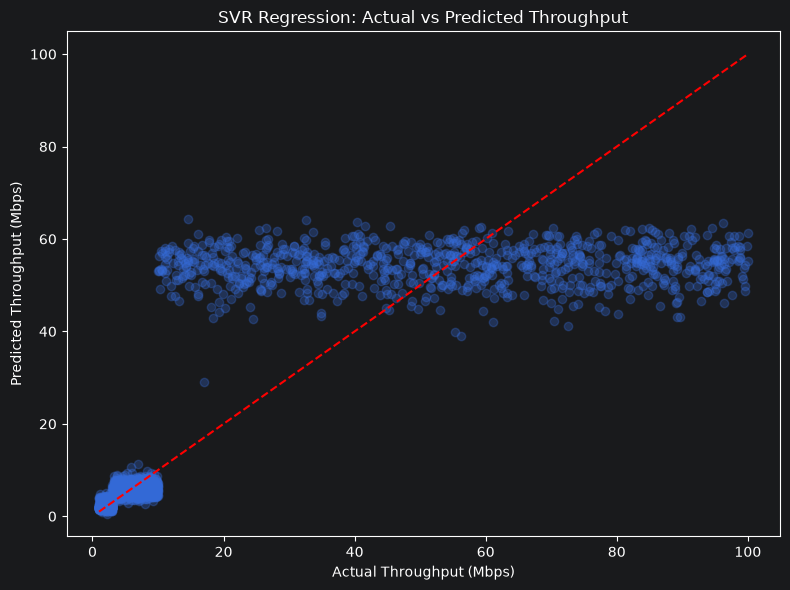

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_test,
    alpha=0.3
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Throughput (Mbps)")
plt.ylabel("Predicted Throughput (Mbps)")
plt.title("SVR Regression: Actual vs Predicted Throughput")

plt.tight_layout()
plt.show()

## Save the Trained SVR Pipeline

The complete trained SVR pipeline, including feature preprocessing and the regression model, is saved as a Joblib file.

The saved pipeline can later be loaded directly by the Streamlit application without retraining the model.

In [12]:
model_path = "../models/svr.joblib"

joblib.dump(
    svr_pipeline,
    model_path
)

print(f"SVR pipeline saved successfully to: {model_path}")

SVR pipeline saved successfully to: ../models/svr.joblib
